In [6]:
import numpy as np

r2 = 0.0525

r1 = (1+r2/2)**2 - 1


r4 = (1+r1)**(1/4) - 1

print(4*r4)
print(f"r1:{r1}")



0.05215991787096197
r1:0.05318906250000022


In [10]:
np.log(1.0417)


np.float64(0.04085399400826612)

In [16]:
r = 0.16

(30000 * (1+r/365)**365 - 30000) / 30000






0.17346973047756548

In [17]:
(1+0.01)**365

37.78343433288728

In [19]:
import os
import pandas as pd
import numpy as np
from tqdm import tqdm

gamma_list = np.arange(0.0001, 0.0501, 0.0001)
sigma_list = np.arange(0.1, 2.1, 0.1)
total_combinations = len(gamma_list) * len(sigma_list)
pbar = tqdm(total=total_combinations, desc="Processing parameter combinations")
base_dir = '/Users/haofu/Desktop/AMM/Dynamic_AMM/Theta/results'

dfs = []
for gamma in gamma_list:
    for sigma in sigma_list:
        d = f"{base_dir}/gamma_{gamma:.4f}_sigma_{sigma:.2f}"
        csv_path = f"{d}/theta_info.csv"
        if os.path.exists(csv_path):
            df = pd.read_csv(csv_path)
            df["gamma"] = round(gamma, 4)
            df["sigma"] = round(sigma, 2)
            dfs.append(df)
        pbar.update(1)
pbar.close()

results_df = pd.concat(dfs, ignore_index=True)
results_df.to_csv("/Users/haofu/Desktop/AMM/Dynamic_AMM/Theta/theta_info_all.csv", index=False)

Processing parameter combinations: 100%|██████████| 10000/10000 [00:07<00:00, 1291.19it/s]


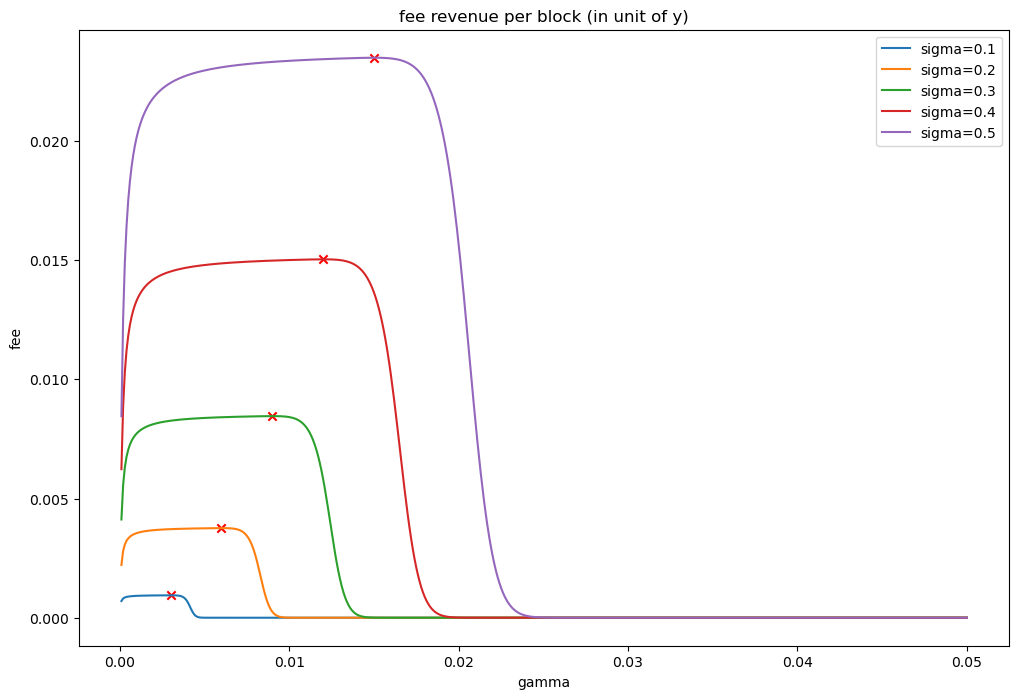

In [34]:
import matplotlib.pyplot as plt
results_df = pd.read_csv(f"/Users/haofu/Desktop/AMM/Dynamic_AMM/Theta/theta_info_all.csv")
plt.figure(figsize=(12, 8))
for s in sigma_list[:5]:
    s = round(s, 2)
    df_fix_sigma = results_df[(results_df['sigma'] == s)]
    gamma_max_fee = df_fix_sigma['gamma'][df_fix_sigma['E_fee_total'].idxmax()]
    plt.scatter(gamma_max_fee, df_fix_sigma['E_fee_total'][df_fix_sigma['gamma'] == gamma_max_fee], color='red', marker='x')
    plt.plot(df_fix_sigma['gamma'], df_fix_sigma['E_fee_total'], label=f'sigma={s}')
    # plt.plot(df_fix_sigma['gamma'], df_fix_sigma['fee_at_mid'], label=f'fee at mid')
plt.xlabel('gamma')
plt.ylabel('fee')
plt.title(f'fee revenue per block (in unit of y)')
plt.legend()
plt.show()


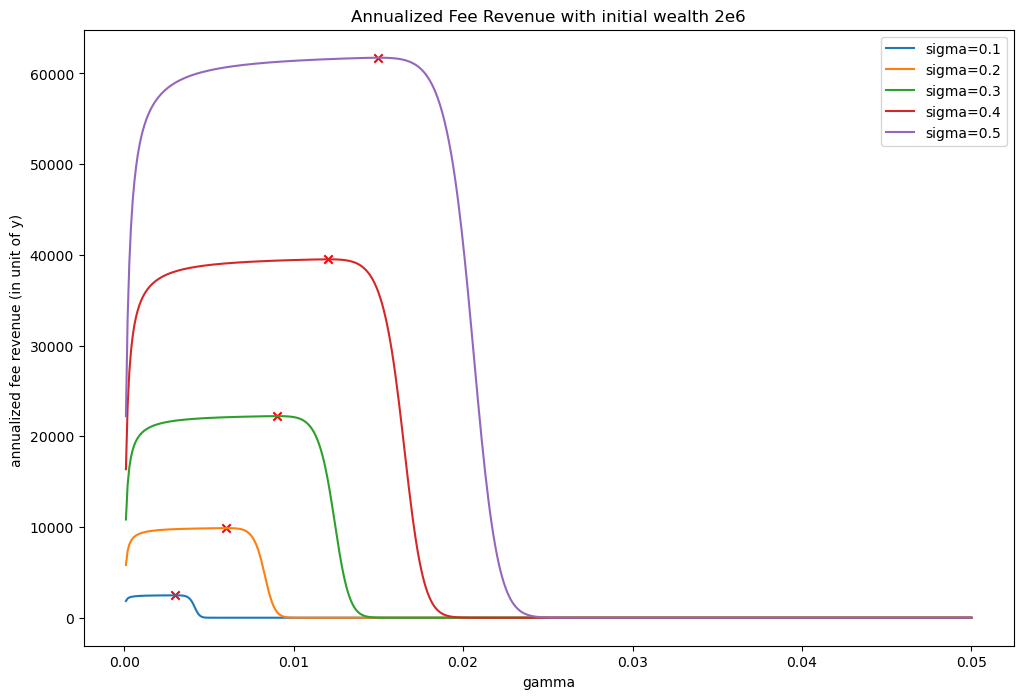

In [33]:
import matplotlib.pyplot as plt
results_df = pd.read_csv(f"/Users/haofu/Desktop/AMM/Dynamic_AMM/Theta/theta_info_all.csv")
plt.figure(figsize=(12, 8))
for s in sigma_list[:5]:
    s = round(s, 2)
    # how many 12-second in one year
    num_12_seconds = 365*24*60*60/12
    df_fix_sigma = results_df[(results_df['sigma'] == s)]
    gamma_max_fee = df_fix_sigma['gamma'][df_fix_sigma['E_fee_total'].idxmax()]
    plt.scatter(gamma_max_fee, df_fix_sigma['E_fee_total'][df_fix_sigma['gamma'] == gamma_max_fee] * num_12_seconds, color='red', marker='x')
    plt.plot(df_fix_sigma['gamma'], df_fix_sigma['E_fee_total'] * num_12_seconds, label=f'sigma={s}')
    # plt.plot(df_fix_sigma['gamma'], df_fix_sigma['fee_at_mid'], label=f'fee at mid')
plt.xlabel('gamma')
plt.ylabel('annualized fee revenue (in unit of y) ')
plt.title(f'Annualized Fee Revenue with initial wealth 2e6')
plt.legend()
plt.show()


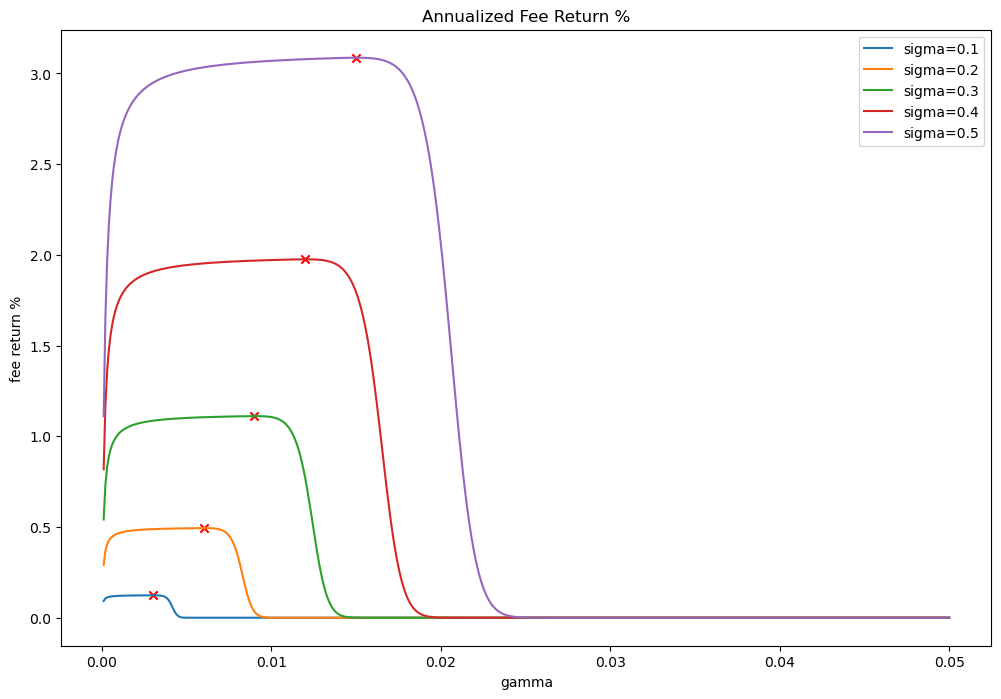

In [35]:
import matplotlib.pyplot as plt
results_df = pd.read_csv(f"/Users/haofu/Desktop/AMM/Dynamic_AMM/Theta/theta_info_all.csv")
plt.figure(figsize=(12, 8))
initial_wealth = 2e6
for s in sigma_list[:5]:
    s = round(s, 2)
    # how many 12-second in one year
    num_12_seconds = 365*24*60*60/12
    df_fix_sigma = results_df[(results_df['sigma'] == s)]
    gamma_max_fee = df_fix_sigma['gamma'][df_fix_sigma['E_fee_total'].idxmax()]
    plt.scatter(gamma_max_fee, df_fix_sigma['E_fee_total'][df_fix_sigma['gamma'] == gamma_max_fee] * num_12_seconds * 100 / initial_wealth, color='red', marker='x')
    plt.plot(df_fix_sigma['gamma'], df_fix_sigma['E_fee_total'] * num_12_seconds * 100 / initial_wealth, label=f'sigma={s}')
    # plt.plot(df_fix_sigma['gamma'], df_fix_sigma['fee_at_mid'], label=f'fee at mid')
plt.xlabel('gamma')
plt.ylabel('fee return %')
plt.title(f'Annualized Fee Return %')
plt.legend()
plt.show()


In [1]:
import numpy as np
from scipy.stats import norm

def analytical_incoming_fee(theta, gamma, sigma, x=1e6, L=1e6, delta_t=1/(365*24)):
    # x = 1e6
    y = L**2 / x
    p0 = (y/x) * (1-gamma)**(-theta)

    sdt = sigma * np.sqrt(delta_t)

    d1 = (np.log((1-gamma) * y / (p0 * x))) / sdt
    d2 = (np.log(y / ((1-gamma) * x * p0))) / sdt

    alpha = L * np.sqrt((1-gamma)*p0) * np.exp(- sigma**2 * delta_t / 8.0)

    incoming_fee = gamma/(1-gamma) * (
        alpha * (norm.cdf(d1) + norm.cdf(-d2))
        - p0*x*norm.cdf(d1 - sdt/2.0)
        - y*norm.cdf(-d2 - sdt/2.0)
    )
    return incoming_fee


results = []
theta = 0
gamma = 0.0001
sigma = 0.1


for x in [5000, 10000, 100000, 500000]:
    fee = analytical_incoming_fee(theta, gamma, sigma, x=x)
    results.append({
        "x": x,
        "fee": fee
    })

print(results)

[{'x': 5000, 'fee': np.float64(7.560065838110686)}, {'x': 10000, 'fee': np.float64(3.780032919055343)}, {'x': 100000, 'fee': np.float64(0.37800329190559023)}, {'x': 500000, 'fee': np.float64(0.07560065838109709)}]


In [2]:
import numpy as np
from scipy.stats import norm

def analytical_incoming_fee(theta, gamma, sigma, L=1e6, delta_t=1/(365*24)):
    # x = 1e6
    y = 1e6
    x = L**2 / y
    p0 = (y/x) * (1-gamma)**(-theta)

    sdt = sigma * np.sqrt(delta_t)

    d1 = (np.log((1-gamma) * y / (p0 * x))) / sdt
    d2 = (np.log(y / ((1-gamma) * x * p0))) / sdt

    alpha = L * np.sqrt((1-gamma)*p0) * np.exp(- sigma**2 * delta_t / 8.0)

    incoming_fee = gamma/(1-gamma) * (
        alpha * (norm.cdf(d1) + norm.cdf(-d2))
        - p0*x*norm.cdf(d1 - sdt/2.0)
        - y*norm.cdf(-d2 - sdt/2.0)
    )
    return incoming_fee


results = []
theta = 0
gamma = 0.0001
sigma = 0.1


for L in [5000, 10000, 100000, 500000]:
    fee = analytical_incoming_fee(theta, gamma, sigma, L = L)
    results.append({
        "x": x,
        "fee": fee
    })

print(results)

[{'x': 500000, 'fee': np.float64(0.03780032919054854)}, {'x': 500000, 'fee': np.float64(0.03780032919054854)}, {'x': 500000, 'fee': np.float64(0.03780032919054854)}, {'x': 500000, 'fee': np.float64(0.03780032919054854)}]


In [5]:
import numpy as np
N = 10

x = np.linspace(-1, 1, N)
print(x)
print((x[:-1] + x[1:]) / 2)


[-1.         -0.77777778 -0.55555556 -0.33333333 -0.11111111  0.11111111
  0.33333333  0.55555556  0.77777778  1.        ]
[-0.88888889 -0.66666667 -0.44444444 -0.22222222  0.          0.22222222
  0.44444444  0.66666667  0.88888889]


In [12]:
y = (x[:-1] + x[1:]) / 2
y
# print(np.append(y, np.array([-1, 1])))
print(np.concatenate([y, [-1, 1]]))


[-0.88888889 -0.66666667 -0.44444444 -0.22222222  0.          0.22222222
  0.44444444  0.66666667  0.88888889 -1.          1.        ]
